In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from training_defs import *

# from pathlib import Path
# project_root = Path.cwd().resolve().parents[2]
# sys.path.append(str(project_root))

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [25]:
def soil_shape_function(x):
    return np.sin(x) ** 4

In [26]:
incident_angle = np.pi/4    
    # Incident angle. Must be between +pi/2 to -pi/2. Cannot exceed these values.
incoming_intensity = 1365 # Typical top of atmosphere flux
viewing_angle = -np.pi/6
x_max = 10                
    # half the width of selected area

if incident_angle >= 0:
    x_edge = x_max
else:
    x_edge = -x_max

y_min = soil_shape_function(x_edge)
y_max = soil_shape_function(-x_edge) + (2*x_edge)/np.arctan(incident_angle)
y_max += 4
# The y_max is estimated by taking the value of the soil shape at the other edge and then doing a linear increase to the other side.
# Added padding to account for any weird quirks of soil shape.
print(y_min, y_max)

0.08759171138677126 34.12782685004798


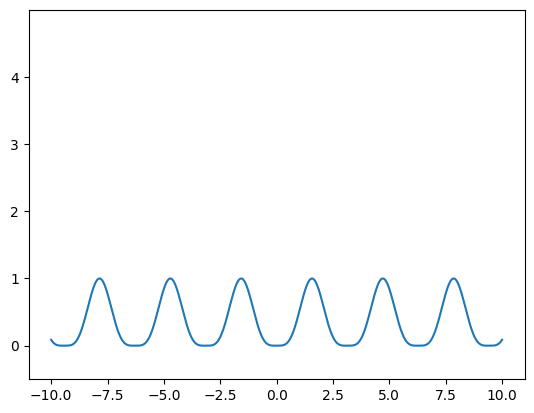

In [27]:
# Plot a graph of soil shape
accuracy = 100 # Not sure how to describe this one in particular...
_xvalues = np.asarray([i/accuracy for i in range((-x_max) * accuracy, (x_max * accuracy) + 1)])
plt.ylim(min(soil_shape_function(_xvalues))-0.5, max(soil_shape_function(_xvalues)) + 4)
plt.plot(_xvalues, soil_shape_function(_xvalues))
plt.show()

In [28]:
# Iterate many times
epochs = 5
N = 10000
calculated_BRDF = []
for epoch in range(epochs):

    # Random sample of y values
    y = np.random.uniform(y_min, y_max,N)

    # Measure intensity:
    measured_intensities = []
    for y_i in y:
        ray_validity, x = ray_trace(incident_angle, soil_shape_function, x_max, y_i, x_edge)
        if ray_validity:
            measured_intensities.append(calc_point_measured_intensity(viewing_angle, incoming_intensity, soil_shape_function, x))
    print(f'Number of accepted light rays: {len(measured_intensities)}')

    # Calculating pi times BRDF
    BRDF = calc_wavelength_BRDF(incident_angle, measured_intensities)
    calculated_BRDF.append(BRDF)
    print(f'Epoch {epoch}. Calculated BRDF: {BRDF/np.pi}')

print(f'Mean BRDF = {(sum(calculated_BRDF)/len(calculated_BRDF))/np.pi:.5f}')

Number of accepted light rays: 4373
Epoch 0. Calculated BRDF: 0.8434888117039175
Number of accepted light rays: 4435
Epoch 1. Calculated BRDF: 0.8425023974328533
Number of accepted light rays: 4497
Epoch 2. Calculated BRDF: 0.8398735441598918
Number of accepted light rays: 4350
Epoch 3. Calculated BRDF: 0.8334852907953454
Number of accepted light rays: 4407
Epoch 4. Calculated BRDF: 0.8360704792220329
Mean BRDF = 0.83908
